# IPL MATCH DATA ANALYSIS



In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./data/matches.csv")
df_d = pd.read_csv("./data/deliveries.csv")
# Same franchise, different names across seasons
TEAM_RENAME = {
    "Delhi Daredevils": "Delhi Capitals",
    "Rising Pune Supergiants": "Rising Pune Supergiant",
    # "Deccan Chargers": "Sunrisers Hyderabad",  # debatable - technically a new franchise
}

# Q1 - Count the total number of matches conducted in 2008.

In [28]:
print("\nQ1 - Count the total number of matches conducted in 2008.")
print("Total number of matches conducted in 2008 are:", df[df["season"] == 2008].shape[0])



Q1 - Count the total number of matches conducted in 2008.
Total number of matches conducted in 2008 are: 58


# Q2 - Find the cities where the maximum and minimum number of matches were conducted.

In [29]:
print("\nQ2 - Find the cities where the maximum and minimum number of matches were conducted.")
counts = df["city"].value_counts()
max_cities = counts[counts == counts.max()].index.tolist()
min_cities = counts[counts == counts.min()].index.tolist()
print("City(ies) with most matches:", max_cities, "-", counts.max(), "matches")
print("City(ies) with least matches:", min_cities, "-", counts.min(), "matches")
print(f"(Note: {df['city'].isna().sum()} matches have no city recorded and are excluded.)\n")


Q2 - Find the cities where the maximum and minimum number of matches were conducted.
City(ies) with most matches: ['Mumbai'] - 101 matches
City(ies) with least matches: ['Bloemfontein'] - 2 matches
(Note: 7 matches have no city recorded and are excluded.)



# Q3 - Find total count of matches city-wise.

In [30]:
print("\nQ3 - Find total count of matches city-wise.")
counts = df["city"].value_counts()
print("Total number of matches in each city:")
print(counts.to_string())
print(f"City not recorded: {df['city'].isna().sum()}\n")


Q3 - Find total count of matches city-wise.
Total number of matches in each city:
city
Mumbai            101
Kolkata            77
Delhi              74
Bangalore          66
Hyderabad          64
Chennai            57
Jaipur             47
Chandigarh         46
Pune               38
Durban             15
Bengaluru          14
Visakhapatnam      13
Centurion          12
Ahmedabad          12
Rajkot             10
Mohali             10
Indore              9
Dharamsala          9
Johannesburg        8
Cape Town           7
Port Elizabeth      7
Cuttack             7
Ranchi              7
Abu Dhabi           7
Raipur              6
Sharjah             6
Kochi               5
Kanpur              4
East London         3
Kimberley           3
Nagpur              3
Bloemfontein        2
City not recorded: 7



# Q4 - Tally the toss decisions each team has taken.

In [31]:
print("\nQ4 - Tally the toss decisions each team has taken.")
toss_winner = df["toss_winner"].replace(TEAM_RENAME)
print(toss_winner.groupby(toss_winner).apply(lambda s: df.loc[s.index, "toss_decision"].value_counts()))


Q4 - Tally the toss decisions each team has taken.
toss_winner                  toss_decision
Chennai Super Kings          bat              48
                             field            41
Deccan Chargers              bat              24
                             field            19
Delhi Capitals               field            59
                             bat              31
Gujarat Lions                field            14
                             bat               1
Kings XI Punjab              field            55
                             bat              26
Kochi Tuskers Kerala         field             5
                             bat               3
Kolkata Knight Riders        field            62
                             bat              30
Mumbai Indians               field            54
                             bat              44
Pune Warriors                bat              11
                             field             9
Rajasthan Royals       

# Q5 - Count the total number of normal and tied matches.

In [32]:
print("\nQ5 - Count the total number of normal and tied matches.")
result_counts = df["result"].value_counts()
print("Normal matches:", int(result_counts.get("normal", 0)))
print("Tied matches:", int(result_counts.get("tie", 0)))
print("No-result matches:", int(result_counts.get("no result", 0)))


Q5 - Count the total number of normal and tied matches.
Normal matches: 743
Tied matches: 9
No-result matches: 4


# Q6 - Find the teams where the result was a tie.

In [33]:
print("\n\nQ6 - Find the teams where the result was a tie.")
print("The teams which were tied:", df.loc[df["result"] == "tie", ["team1", "team2"]].reset_index(drop=True))



Q6 - Find the teams where the result was a tie.
The teams which were tied:                          team1                        team2
0                Gujarat Lions               Mumbai Indians
1             Rajasthan Royals        Kolkata Knight Riders
2              Kings XI Punjab          Chennai Super Kings
3  Royal Challengers Bangalore          Sunrisers Hyderabad
4             Delhi Daredevils  Royal Challengers Bangalore
5             Rajasthan Royals        Kolkata Knight Riders
6             Rajasthan Royals              Kings XI Punjab
7        Kolkata Knight Riders               Delhi Capitals
8               Mumbai Indians          Sunrisers Hyderabad


# Q7 - Find the team which won the match by the highest and lowest number of runs.

In [34]:
print("\n\nQ7 - Find the team which won the match by the highest and lowest number of runs.")
df_win = df[df["win_by_runs"] > 0]

win_high = df_win["win_by_runs"].max()
print("Team that won by the highest number of runs, which is", win_high, "is", df.loc[df["win_by_runs"] == win_high, "winner"].unique().tolist()) 

win_low = df_win["win_by_runs"].min()
print("Team that won by the lowest number of runs, which is", win_low, "is", df.loc[df["win_by_runs"] == win_low, "winner"].unique().tolist())



Q7 - Find the team which won the match by the highest and lowest number of runs.
Team that won by the highest number of runs, which is 146 is ['Mumbai Indians']
Team that won by the lowest number of runs, which is 1 is ['Mumbai Indians', 'Kings XI Punjab', 'Delhi Daredevils', 'Chennai Super Kings', 'Gujarat Lions', 'Royal Challengers Bangalore']


# Q8 - Calculate mean, median and standard deviation of win_by_runs.

In [35]:
print("\n\nQ8 - Calculate mean, median and standard deviation of win_by_runs.")

# Since many rows have 0 win_by_run values, computing the mean,median and standard deviation with and without zero values

print("Computing with zero values:")
win_by_runs = df["win_by_runs"]
print("Mean of win_by_runs column:", win_by_runs.mean())
print("Median of win_by_runs column:", win_by_runs.median())
print("Standard Deviation of win_by_runs column:", win_by_runs.std())

print("\nComputing without zero values:")
win_by_runs_nonzero = df.loc[df["win_by_runs"] > 0, "win_by_runs"]
print("Mean of win_by_runs column:", win_by_runs_nonzero.mean())
print("Median of win_by_runs column:", win_by_runs_nonzero.median())
print("Standard Deviation of win_by_runs column:", win_by_runs_nonzero.std())



Q8 - Calculate mean, median and standard deviation of win_by_runs.
Computing with zero values:
Mean of win_by_runs column: 13.283068783068783
Median of win_by_runs column: 0.0
Standard Deviation of win_by_runs column: 23.47114399366638

Computing without zero values:
Mean of win_by_runs column: 29.798219584569733
Median of win_by_runs column: 22.0
Standard Deviation of win_by_runs column: 27.281615502747165


# Q9 - Find the venue where the team won by the highest and lowest number of runs.

In [36]:
print("\n\nQ9 - Find the venue where the team won by the highest and lowest number of runs.")
df_win = df[df["win_by_runs"] > 0]

win_high = df_win["win_by_runs"].max()
print("Venue of the match where team won by highest number of runs:", df.loc[df["win_by_runs"] == win_high, "venue"].unique().tolist()) 

win_low = df_win["win_by_runs"].min()
print("Venue of the match where team won by lowest number of runs:", df.loc[df["win_by_runs"] == win_low, "venue"].unique().tolist()) 



Q9 - Find the venue where the team won by the highest and lowest number of runs.
Venue of the match where team won by highest number of runs: ['Feroz Shah Kotla']
Venue of the match where team won by lowest number of runs: ['Rajiv Gandhi International Stadium, Uppal', 'Wankhede Stadium', 'New Wanderers Stadium', 'Feroz Shah Kotla', 'Subrata Roy Sahara Stadium', 'MA Chidambaram Stadium, Chepauk', 'Punjab Cricket Association IS Bindra Stadium, Mohali', 'M. Chinnaswamy Stadium', 'Rajiv Gandhi Intl. Cricket Stadium']


# Q10 - Find the players who have won Player of the Match more than 3 times.

In [37]:
print("\n\nQ10 - Find the players who have won Player of the Match more than 3 times.")
pom_value_count = df["player_of_match"].value_counts()
print("The list of players who got player of the match more than 3 times:", pom_value_count[pom_value_count > 3].to_string())



Q10 - Find the players who have won Player of the Match more than 3 times.
The list of players who got player of the match more than 3 times: player_of_match
CH Gayle            21
AB de Villiers      20
MS Dhoni            17
DA Warner           17
RG Sharma           17
YK Pathan           16
SR Watson           15
SK Raina            14
G Gambhir           13
MEK Hussey          12
V Kohli             12
AM Rahane           12
DR Smith            11
V Sehwag            11
A Mishra            11
AD Russell          11
KA Pollard          10
JH Kallis           10
SP Narine            9
AT Rayudu            9
SE Marsh             9
SR Tendulkar         8
Harbhajan Singh      8
RA Jadeja            8
UT Yadav             8
Rashid Khan          7
RV Uthappa           7
AC Gilchrist         7
RR Pant              6
S Dhawan             6
A Nehra              6
BJ Hodge             6
SL Malinga           6
M Vijay              6
HH Pandya            6
Yuvraj Singh         5
SPD Smith   

# Q11 - Find all deliveries where the batsman scored a six.

In [38]:
print("\n\nQ11 - Find all deliveries where the batsman scored a six.")
sixes = df_d[df_d["batsman_runs"] == 6].reset_index(drop=True)
print("Total deliveries where the batsman scored a six:", len(sixes))
print("Sample:\n", sixes.head(10).to_string())



Q11 - Find all deliveries where the batsman scored a six.
Total deliveries where the batsman scored a six: 8170
Sample:
    match_id  inning                 batting_team                 bowling_team  over  ball       batsman    non_striker       bowler  is_super_over  wide_runs  bye_runs  legbye_runs  noball_runs  penalty_runs  batsman_runs  extra_runs  total_runs player_dismissed dismissal_kind fielder
0         1       1          Sunrisers Hyderabad  Royal Challengers Bangalore     2     4     DA Warner       S Dhawan  A Choudhary              0          0         0            0            0             0             6           0           6              NaN            NaN     NaN
1         1       1          Sunrisers Hyderabad  Royal Challengers Bangalore     8     4  MC Henriques       S Dhawan      TM Head              0          0         0            0            0             0             6           0           6              NaN            NaN     NaN
2         1       1

# Q12 - Compute the average runs scored in matches in all the venues.

In [39]:
print("\n\nQ12 - Compute the average runs scored in matches in all the venues.")
# total_runs includes extras; drop super overs so only regulation innings count
reg = df_d[df_d["is_super_over"] == 0]
runs_per_match = reg.groupby("match_id")["total_runs"].sum().reset_index()
runs_per_match = runs_per_match.merge(df[["id", "venue"]], left_on="match_id", right_on="id")
print("Average runs scored per match at each venue:")
print(runs_per_match.groupby("venue")["total_runs"].mean())



Q12 - Compute the average runs scored in matches in all the venues.
Average runs scored per match at each venue:
venue
ACA-VDCA Stadium                                        329.000000
Barabati Stadium                                        325.428571
Brabourne Stadium                                       349.272727
Buffalo Park                                            266.333333
De Beers Diamond Oval                                   299.000000
Dr DY Patil Sports Academy                              282.941176
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium     283.727273
Dubai International Cricket Stadium                     294.857143
Eden Gardens                                            309.831169
Feroz Shah Kotla                                        311.880597
Feroz Shah Kotla Ground                                 322.857143
Green Park                                              324.500000
Himachal Pradesh Cricket Association Stadium            321.888889
Holkar C

# Q13 - Find the umpires who umpired the maximum number of times.

In [40]:
print("\n\nQ13 - Find the umpires who umpired the maximum number of times.")
umps = pd.concat([df["umpire1"], df["umpire2"], df["umpire3"]]).value_counts()
print(umps.idxmax(),"umpired the most")
print("Umpires who umpired the most:\n", umps.head(5))



Q13 - Find the umpires who umpired the maximum number of times.
S Ravi umpired the most
Umpires who umpired the most:
 S Ravi             114
HDPK Dharmasena     87
C Shamshuddin       83
AK Chaudhary        58
SJA Taufel          55
Name: count, dtype: int64


# Q14 - Find the total number of matches played in each season.

In [41]:
print("\n\nQ14 - Find the total number of matches played in each season.")
print("Total number of matches played in each season are:",df["season"].value_counts().sort_index())



Q14 - Find the total number of matches played in each season.
Total number of matches played in each season are: season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
Name: count, dtype: int64


# Q15 - Find total runs scored in each season.

In [42]:
print("\n\nQ15 - Find total runs scored in each season.")
reg = df_d[df_d["is_super_over"] == 0]
runs_per_match = reg.groupby("match_id")["total_runs"].sum().reset_index()
runs_per_match = runs_per_match.merge(df[["id", "season"]], left_on="match_id", right_on="id")
print("Total runs scored in each season:\n", runs_per_match.groupby("season")["total_runs"].sum())



Q15 - Find total runs scored in each season.
Total runs scored in each season:
 season
2008    17937
2009    16320
2010    18864
2011    21154
2012    22453
2013    22541
2014    18909
2015    18332
2016    18862
2017    18769
2018    20706
2019    20270
Name: total_runs, dtype: int64


# Q16 - Calculate total number of runs scored by each batsman and display top 10.

In [43]:
print("\n\nQ16 - Calculate total number of runs scored by each batsman and display top 10.")
top_10_runs_scorres = df_d.groupby("batsman")["batsman_runs"].sum().sort_values(ascending=False).head(10)
print("Top 10 run scorres are:\n", top_10_runs_scorres)



Q16 - Calculate total number of runs scored by each batsman and display top 10.
Top 10 run scorres are:
 batsman
V Kohli           5434
SK Raina          5415
RG Sharma         4914
DA Warner         4741
S Dhawan          4632
CH Gayle          4560
MS Dhoni          4477
RV Uthappa        4446
AB de Villiers    4428
G Gambhir         4223
Name: batsman_runs, dtype: int64


# Q17 - Compute the total number of wickets taken by each bowler.

In [44]:
print("\n\nQ17 - Compute the total number of wickets taken by each bowler.")
bowler_credit = {"caught", "bowled", "lbw", "stumped", "caught and bowled", "hit wicket"}
bowler_wickets = df_d[df_d["dismissal_kind"].isin(bowler_credit)]
per_bowler_wickets = bowler_wickets.groupby("bowler").size().sort_values(ascending = False)
print("Total number of wickets taken by each bowler:\n",per_bowler_wickets.to_string())



Q17 - Compute the total number of wickets taken by each bowler.
Total number of wickets taken by each bowler:
 bowler
SL Malinga           170
A Mishra             156
Harbhajan Singh      150
PP Chawla            149
DJ Bravo             147
B Kumar              133
R Ashwin             125
SP Narine            122
UT Yadav             119
RA Jadeja            108
A Nehra              106
R Vinay Kumar        105
Z Khan               102
YS Chahal            100
DW Steyn              96
SR Watson             92
MM Sharma             91
P Kumar               90
RP Singh              90
PP Ojha               89
DS Kulkarni           86
JA Morkel             85
Sandeep Sharma        83
JJ Bumrah             82
IK Pathan             80
Imran Tahir           79
M Morkel              77
JD Unadkat            77
L Balaji              76
MM Patel              74
MJ McClenaghan        71
I Sharma              71
R Bhatia              71
AR Patel              71
CH Morris             70
AB Di

# Q18 - Compute batting averages and display top 10.

In [45]:
print("\n\nQ18 - Compute batting averages and display top 10.")
MIN_INNINGS = 10
runs = df_d.groupby("batsman")["batsman_runs"].sum()
innings = df_d.groupby("batsman")["match_id"].nunique()
dismissals = df_d["player_dismissed"].value_counts()

avg = (runs / dismissals).replace([np.inf, -np.inf], np.nan).dropna()
avg = avg[innings.reindex(avg.index).fillna(0) >= MIN_INNINGS]
print(f"Top 10 batting averages (min {MIN_INNINGS} innings):")
print(avg.sort_values(ascending=False).head(10))



Q18 - Compute batting averages and display top 10.
Top 10 batting averages (min 10 innings):
batsman
J Bairstow        58.500000
HM Amla           44.384615
Iqbal Abdulla     44.000000
DA Warner         43.100000
KL Rahul          42.829787
MS Dhoni          42.638095
CH Gayle          41.834862
AB de Villiers    40.254545
JP Duminy         40.019608
LMP Simmons       39.962963
dtype: float64


# Q19 - Visualize toss decisions across all seasons.



Q19 - Visualize toss decisions across all seasons.


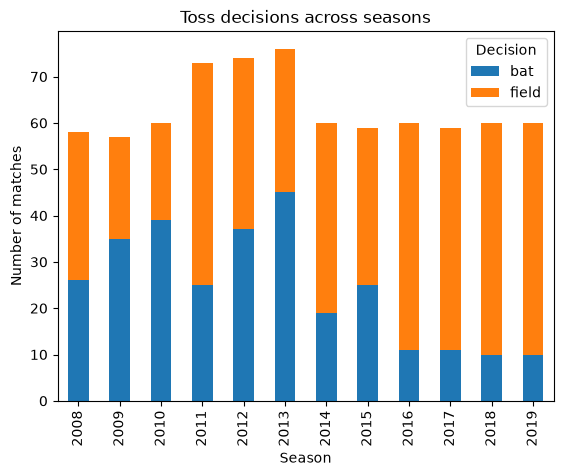

In [46]:
print("\n\nQ19 - Visualize toss decisions across all seasons.")

toss_by_season = df.groupby(["season","toss_decision"]).size().unstack()
toss_by_season.plot(kind="bar", stacked = True)
plt.title('Toss decisions across seasons')
plt.xlabel('Season')
plt.ylabel('Number of matches')
plt.legend(title='Decision')
plt.show()

# Q20 - Visualize Total Matches vs Winning Matches vs Win Rate for all teams.



Q20 - Visualize Total Matches vs Winning Matches vs Win Rate for all teams.
                             played  won   win_rate
Chennai Super Kings             164  100  60.975610
Mumbai Indians                  187  109  58.288770
Sunrisers Hyderabad             108   58  53.703704
Kolkata Knight Riders           178   92  51.685393
Rajasthan Royals                147   75  51.020408
Rising Pune Supergiant           30   15  50.000000
Royal Challengers Bangalore     180   84  46.666667
Kings XI Punjab                 176   82  46.590909
Delhi Capitals                  177   77  43.502825
Gujarat Lions                    30   13  43.333333
Kochi Tuskers Kerala             14    6  42.857143
Deccan Chargers                  75   29  38.666667
Pune Warriors                    46   12  26.086957


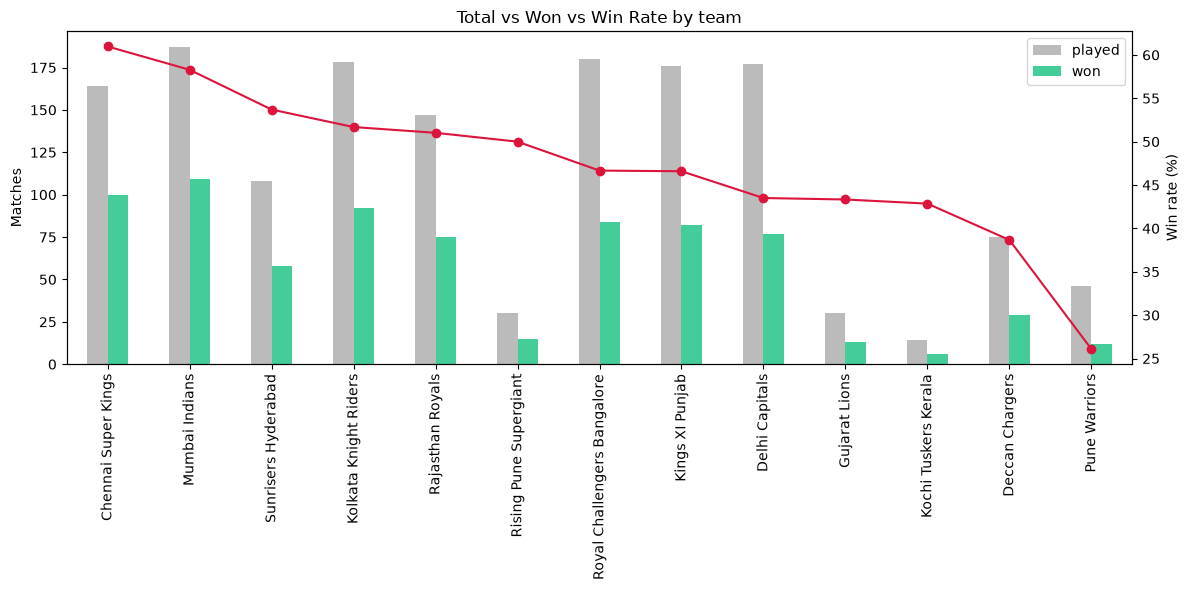

In [47]:
print("\n\nQ20 - Visualize Total Matches vs Winning Matches vs Win Rate for all teams.")
t1 = df["team1"].replace(TEAM_RENAME)
t2 = df["team2"].replace(TEAM_RENAME)
winner = df["winner"].replace(TEAM_RENAME)

team_played = pd.concat([t1, t2]).value_counts()
team_wins = winner.value_counts()
team_summary = pd.DataFrame({"played": team_played, "won": team_wins}).fillna(0)
team_summary["win_rate"] = team_summary["won"] / team_summary["played"] * 100
team_summary = team_summary.sort_values("win_rate", ascending=False)
print(team_summary)

fig, ax1 = plt.subplots(figsize=(12, 6))
team_summary[["played", "won"]].plot(kind="bar", ax=ax1, color=["#bbb", "#4c9"])
ax1.set_ylabel("Matches")
ax2 = ax1.twinx()
ax2.plot(range(len(team_summary)), team_summary["win_rate"], "o-", color="crimson", label="win rate %")
ax2.set_ylabel("Win rate (%)")
ax1.set_title("Total vs Won vs Win Rate by team")
fig.tight_layout()
plt.show()

# Q21 - Find the distribution of the teams who won the matches.



Q21 - Find the distribution of the teams who won the matches.


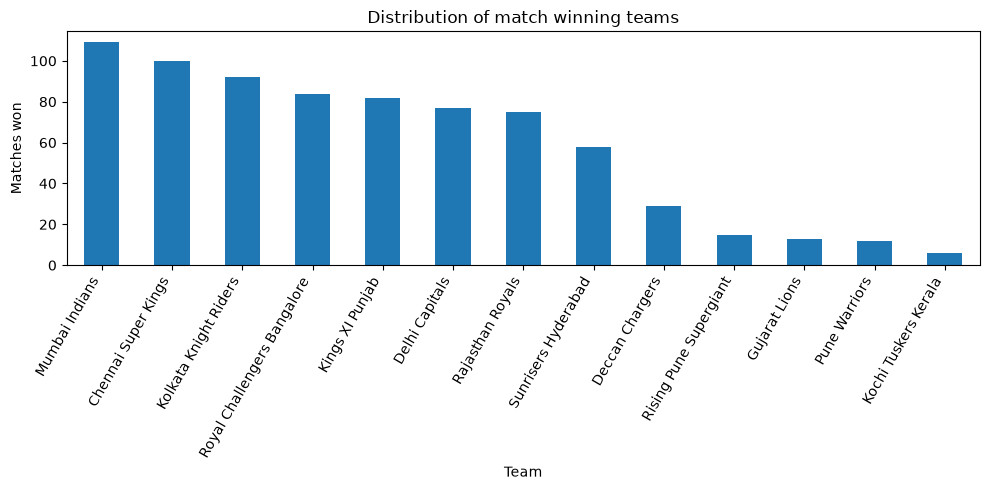

In [48]:
print("\n\nQ21 - Find the distribution of the teams who won the matches.")
team_wins = df["winner"].replace(TEAM_RENAME).value_counts()
team_wins.plot(kind="bar",figsize=(10,5))
plt.title('Distribution of match winning teams')
plt.xlabel('Team')
plt.ylabel('Matches won')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

# Q22 - Visualize the toss outcomes of all teams.



Q22 - Visualize the toss outcomes of all teams.


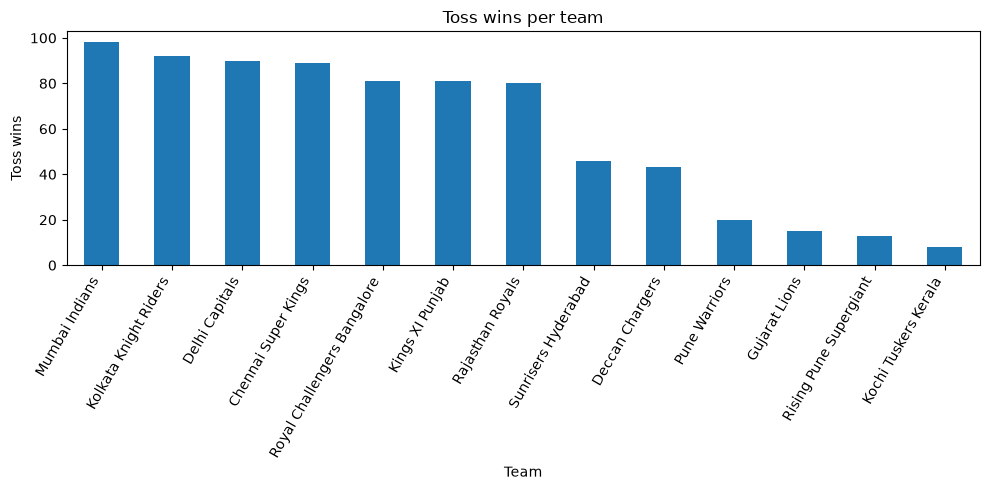

In [49]:
print("\n\nQ22 - Visualize the toss outcomes of all teams.")

toss_wins = df["toss_winner"].replace(TEAM_RENAME).value_counts()

toss_wins.plot(kind="bar",figsize=(10,5))
plt.title('Toss wins per team')
plt.xlabel('Team')
plt.ylabel('Toss wins')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

# Q23 - Visualize the top 5 teams with the most wins across all seasons.



Q23 - Visualize the top 5 teams with the most wins across all seasons.


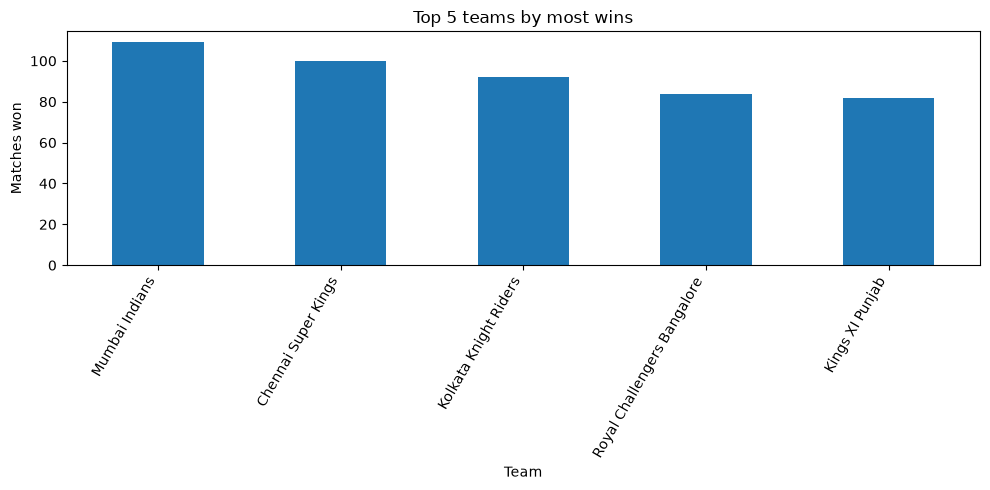

In [50]:
print("\n\nQ23 - Visualize the top 5 teams with the most wins across all seasons.")

team_wins = df["winner"].replace(TEAM_RENAME).value_counts().head(5)

team_wins.plot(kind="bar",figsize=(10,5))
plt.title('Top 5 teams by most wins')
plt.xlabel('Team')
plt.ylabel('Matches won')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()